#Set up

##Load libraries

In [10]:
%pip install pyarrow pandas xgboost imbalanced-learn scikit-learn


In [ ]:
import pandas as pd
import numpy as np
from typing import List, Optional
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV
from pathlib import Path
import pyarrow.parquet as pq
from pathlib import Path

##Load data

In [14]:
print(Path.cwd())

c:\Users\Uživatel\fraud-decision-system\notebooks


Load data as pandas dataframes and display them for inspection

In [17]:
from pathlib import Path
import pyarrow.parquet as pq

root = Path.cwd().parent
data_dir = root / "data" / "raw"

cards = pq.read_table(data_dir / "cards.pq").to_pandas()
transactions = pq.read_table(data_dir / "transactions.pq").to_pandas()
users = pq.read_table(data_dir / "users.pq").to_pandas()

In [16]:
display(cards.head())

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [15]:
display(transactions.head())

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2018,1,2,06:28,$130.95,Chip Transaction,5817218446178736267,La Verne,CA,91750.0,5912,None,No
1,0,0,2018,1,5,06:02,$129.34,Chip Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No
2,0,0,2018,1,5,17:56,$8.54,Online Transaction,6455213054093379528,ONLINE,None,NaN,5815,None,No
3,0,0,2018,1,6,06:23,$115.71,Chip Transaction,4722913068560264812,Alhambra,CA,91801.0,5411,None,No
4,0,0,2018,1,11,06:02,$107.50,Chip Transaction,2027553650310142703,Mira Loma,CA,91752.0,5541,None,No


In [16]:
display(users.head())

,User,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,Address,Apartment,City,State,Zipcode,Latitude,Longitude,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards
0,0,Hazel Robinson,53,66,1966,11,Female,462 Rose Lane,NaN,La Verne,CA,91750,34.15,-117.76,$29278,$59696,$127613,787,5
1,1,Sasha Sadr,53,68,1966,12,Female,3606 Federal Boulevard,NaN,Little Neck,NY,11363,40.76,-73.74,$37891,$77254,$191349,701,5
2,2,Saanvi Lee,81,67,1938,11,Female,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.89,$22681,$33483,$196,698,5
3,3,Everlee Clark,63,63,1957,1,Female,3 Madison Street,NaN,New York,NY,10069,40.71,-73.99,$163145,$249925,$202328,722,4
4,4,Kyle Peterson,43,70,1976,9,Male,9620 Valley Stream Drive,NaN,San Francisco,CA,94117,37.76,-122.44,$53797,$109687,$183855,675,1


# Exploratory data analysis

In [4]:
print('cards:', cards.shape)
print('transactions:', transactions.shape)
print('users:', users.shape)

fraud_counts = transactions['Is Fraud?'].value_counts(dropna=False)
display(fraud_counts.to_frame('count'))
display((fraud_counts / len(transactions)).to_frame('proportion'))

print('\nSample of key categorical columns:')
for col in ['Type', 'Errors?', 'MCC', 'Merchant State', 'Merchant City']:
    if col in transactions.columns:
        print(f"\n{col}: {transactions[col].nunique()} unique values")
        display(transactions[col].value_counts(dropna=False).head(8))

NameError: name 'cards' is not defined

In [ ]:
print('Missing values in transactions:')
missing_summary = pd.DataFrame({
    'missing_count': transactions.isnull().sum(),
    'missing_percent': (transactions.isnull().mean() * 100).round(2)
})

display(missing_summary.sort_values('missing_count', ascending=False).head(15))

#Joining the data (unsuccessful)

In [ ]:
# cards=cards.drop(columns=['Card Number',"CVV", "Has Chip"]) #dropping ["Has Chip"] because we already have this information in the transactions dataset
# users=users.drop(columns=['Person',"Birth Year", "Birth Month"]) #dropping ["Birth Year"] because we already have this information in the "Current Age" column

In [ ]:
transactions_full = (transactions
                     .merge(users, on='User', how='left')
                    .merge(cards, left_on='Card', right_on='CARD INDEX', how='left'))

Before joining the data, lets drop duplicates

In [ ]:
print(len(transactions['Card']))

3782053


#Data wrangling and feature extraction

##transactions

Lets inspect if the data types are as expected

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3782053 entries, 0 to 3782052
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   User            int64  
 1   Card            int64  
 2   Year            int64  
 3   Month           int64  
 4   Day             int64  
 5   Time            object 
 6   Amount          object 
 7   Use Chip        object 
 8   Merchant Name   int64  
 9   Merchant City   object 
 10  Merchant State  object 
 11  Zip             float64
 12  MCC             int64  
 13  Errors?         object 
 14  Is Fraud?       object 
dtypes: float64(1), int64(7), object(7)
memory usage: 432.8+ MB


The "Is Fraud?" column is currently a string column- lets convert it to numeric format. Also, lets check if it has only values "Yes" or "No" first.

In [18]:
transactions["Is Fraud?"].unique()

array(['No', 'Yes'], dtype=object)

No unexpected values are present.

In [19]:
transactions['Is Fraud?'] = transactions['Is Fraud?'].map({'No': 0, 'Yes': 1})

Columns "Amount" and "Time" should be converted from string to float and date_time, respectively.

In [20]:
transactions['Amount'] = transactions['Amount'].str.replace('$','').astype(float)



In [21]:
type(transactions['Time'] [0])

str

In [22]:
transactions['Time'] = pd.to_datetime(transactions['Time'], format='%H:%M').dt.time

The ZIP should not be a float, we do not want it to be treated as a numeric variable.

In [23]:
transactions['Zip'] = transactions['Zip'].astype('Int64').astype(str)


Lets check the presence of missing values.

In [24]:
missing_summary = pd.DataFrame({
    'missing_count': transactions.isnull().sum(),
    'missing_percent': (transactions.isnull().mean() * 100).round(2)
})

print(missing_summary)


                missing_count  missing_percent
User                        0             0.00
Card                        0             0.00
Year                        0             0.00
Month                       0             0.00
Day                         0             0.00
Time                        0             0.00
Amount                      0             0.00
Use Chip                    0             0.00
Merchant Name               0             0.00
Merchant City               0             0.00
Merchant State         473483            12.52
Zip                         0             0.00
MCC                         0             0.00
Errors?               3722382            98.42
Is Fraud?                   0             0.00


It appears that the column "Errors?" has a high proportion of missing values. Given the nature of the variable, it probably makes sense. Lets inspect its unique values to assess the information it holds.




In [25]:
print(transactions['Errors?'].unique())

[None 'Insufficient Balance' 'Bad PIN' 'Technical Glitch' 'Bad Expiration'
 'Bad CVV' 'Bad Card Number' 'Bad Card Number,Insufficient Balance'
 'Bad Card Number,Bad CVV' 'Bad PIN,Insufficient Balance' 'Bad Zipcode'
 'Insufficient Balance,Technical Glitch' 'Bad PIN,Technical Glitch'
 'Bad CVV,Insufficient Balance' 'Bad Card Number,Bad Expiration'
 'Bad Expiration,Insufficient Balance' 'Bad Expiration,Technical Glitch'
 'Bad Expiration,Bad CVV' 'Bad Zipcode,Technical Glitch'
 'Bad Zipcode,Insufficient Balance' 'Bad Card Number,Technical Glitch'
 'Bad CVV,Technical Glitch']


It appears that the column "Errors?" holds information on why the transaction has been declined and it may be linked with the probability that the transaction is fraudulent. In effect, it can be claimed that all the values except for "Technical Glitch" may indicate a fraudulent transaction. For instance, values like 'Bad PIN', 'Bad Expiration', 'Bad CVV', 'Bad Card Number' show that incorrect card credentials have been used, which may increase the probability of a fraud. Likewise, the value 'Insufficient Balance' may indicate that the fraudster attempted to wipe out the account by specifying a transaction amount larger than the available balance (which has likely been unknown to them). However, the value 'Technical Glitch' should only indicate technical issues such as problems with the payment terminal or temporary outages of authorization systems. This itself is probably not a good indicator of a fraud. Also, a missing value might indicate a legitimate transaction, since no error has been detected. Therefore, the column will be converted into a binary one (0 if the value is missing or 'Technical Glitch', and 1 otherwise) and subsequently used for prediction.

In [26]:
transactions['Errors_binary'] = transactions['Errors?'].apply(
    lambda x: 0 if (pd.isna(x) or x == 'Technical Glitch') else 1
)


The column "MCC" likely denotes the Merchant Category Code, which may hold valueable information, since certain merchant categories are linked with a higher risk of fraud. Lets create a binary column, which denotes whether a category is generally viewed as high-risk.

In [27]:
print(np.array(sorted(transactions['MCC'].unique())))

[1711 3000 3001 3005 3006 3007 3008 3009 3058 3066 3075 3132 3144 3174
 3256 3260 3359 3387 3389 3390 3393 3395 3405 3504 3509 3596 3640 3684
 3722 3730 3771 3775 3780 4111 4112 4121 4131 4214 4411 4511 4722 4784
 4814 4829 4899 4900 5045 5094 5192 5193 5211 5251 5261 5300 5310 5311
 5411 5499 5533 5541 5621 5651 5655 5661 5712 5719 5722 5732 5733 5812
 5813 5814 5815 5816 5912 5921 5932 5941 5942 5947 5970 5977 6300 7011
 7210 7230 7276 7349 7393 7531 7538 7542 7549 7801 7802 7832 7922 7995
 7996 8011 8021 8041 8043 8049 8062 8099 8111 8931 9402]


In [28]:
#Auxiliary dictionary that maps merchant codes to category description

mcc_dict = {
    1711: "Air Conditioning, Heating and Plumbing Contractors",
    3000: "United Airlines",
    3001: "American Airlines",
    3005: "British Airways",
    3006: "Japan Airlines",
    3007: "Air France",
    3008: "Lufthansa German Airlines",
    3009: "Air Canada",
    3058: "Delta Air Lines",
    3066: "Southwest Airlines",
    3075: "Singapore Airlines",
    3132: "Frontier Airlines",
    3144: "Virgin Atlantic",
    3174: "JetBlue Airlines",
    3256: "Alaska Airlines",
    3260: "Spirit Airlines",
    3359: "Payless Car Rental",
    3387: "Alamo Rent‑A‑Car",
    3389: "Avis Rent‑A‑Car",
    3390: "Dollar Rent‑A‑Car",
    3393: "National Car Rental",
    3395: "Thrifty Rent‑A‑Car",
    3405: "Enterprise Rent‑A‑Car",
    3504: "Hilton Hotels",
    3509: "Marriott Hotels",
    3596: "Wynn Las Vegas",
    3640: "Hyatt Hotels",
    3684: "Budget Host Inns",
    3722: "Wyndham Hotel & Resorts",
    3730: "MGM Grand Hotel",
    3771: "Caesars Hotel and Casino",
    3775: "Sands Resort",
    3780: "Courts & Resorts (misc lodging)",  # approximation
    4111: "Transportation–Suburban and Local Commuter Passenger",
    4112: "Passenger Railways",
    4121: "Taxicabs and Limousines",
    4131: "Bus Lines",
    4214: "Motor Freight Carriers/Trucking and Storage",
    4411: "Cruise Lines",
    4511: "Air Carriers, Airlines – not elsewhere classified",
    4722: "Travel Agencies and Tour Operators",
    4784: "Bridge and Road Fees, Tolls",
    4814: "Telecommunication Services",
    4829: "Wire Transfer Money Orders / Money Transfer",
    4899: "Cable, Satellite and Other Pay Television/Radio Services",
    4900: "Utilities–Electric, Gas, Heating Oil, Water",
    5045: "Computers, Computer Peripheral Equipment, Software",
    5094: "Precious Stones and Metals, Watches and Jewelry",
    5192: "Books, Periodicals and Newspapers",
    5193: "Florists and Floral Supplies",  # approx
    5211: "Lumber and Building Materials",
    5251: "Hardware Stores",
    5261: "Nurseries and Garden Supply Stores",
    5300: "Wholesale Clubs",
    5310: "Metal Service Centers",
    5311: "Department Stores",
    5411: "Grocery Stores, Supermarkets",
    5499: "Miscellaneous Food Stores–Convenience Stores and Specialty Markets",
    5533: "Automotive Parts and Accessories Stores",
    5541: "Service Stations (With or Without Ancillary Services)",
    5621: "Women's Ready-to-Wear Stores",
    5651: "Family Clothing Stores",
    5655: "Sports Apparel and Riding Apparel Stores",
    5661: "Shoe Stores",
    5712: "Furniture, Home Furnishings & Equipment Stores (except Appliances)",
    5719: "Miscellaneous Home Furnishing Specialty Shops",
    5722: "Household Appliance Stores",
    5732: "Electronics Sales",
    5733: "Music Stores, Record Shops",
    5812: "Eating Places, Fast Food Restaurants",
    5813: "Drinking Places (Alcoholic Beverages)—bars, pubs, etc.",
    5814: "Caterers",
    5815: "Digital Goods – Media, Books, Movies, Music",
    5816: "Digital Goods – Games, Applications",
    5912: "Drug Stores and Pharmacies",
    5921: "Package Stores—Beer, Wine, and Liquor",
    5932: "Used Merchandise and Second-Hand Stores",
    5941: "Sporting Goods Stores",
    5942: "Book Stores",
    5947: "Gift, Novelty, and Souvenir Shops",
    5970: "Artist Supply and Craft Stores",
    5977: "Cosmetic Stores",
    6300: "Insurance Sales, underwritten by licensed broker",
    7011: "Hotels, Motels, Resorts (not elsewhere classified)",
    7210: "Laundry, Cleaning and Garment Services",
    7230: "Barber and Beauty Shops",
    7276: "Tax Preparation Services",
    7349: "Cleaning, Maintenance, and Janitorial Services",
    7393: "Detective Services, Protective Services, Security Services",
    7531: "Automotive Body Repair Shops",
    7538: "Automotive Service Stations (except Fuel Dispensers)",
    7542: "Car Washes",
    7549: "Towing Services",
    7801: "Motion Picture Theaters",
    7802: "Video Tape Rental Stores",
    7832: "Motion Picture/Video Tape Production and Distribution",
    7922: "Theatrical Producers (except Motion Picture)",
    7995: "Betting, Wagering, Lottery Tickets",
    7996: "Amusement Parks, Carnivals, Circuses",
    8011: "Doctors (not elsewhere classified)",
    8021: "Dentists and Orthodontists",
    8041: "Chiropractors",
    8043: "Optometrists and Ophthalmic Goods",
    8049: "Podiatrists and Optometrists",
    8062: "Hospitals",
    8099: "Medical Services and Health Practitioners",
    8111: "Legal Services, Attorneys and Counselors",
    8931: "Accounting, Auditing, and Bookkeeping Services",
    9402: "Postal Services—Government Only"
}


In [29]:
transactions['MCC_desc'] = transactions['MCC'].map(mcc_dict)


In [30]:
#Auxiliary dictionary that maps merchant codes whether or not the category is related to higher risk of fraud

mcc_risk_dict = {
    1711: 0,
    3000: 1,  # Airlines
    3001: 1,
    3005: 1,
    3006: 1,
    3007: 1,
    3008: 1,
    3009: 1,
    3058: 1,
    3066: 1,
    3075: 1,
    3132: 1,
    3144: 1,
    3174: 1,
    3256: 1,
    3260: 1,
    3359: 1,  # Car rental
    3387: 1,
    3389: 1,
    3390: 1,
    3393: 1,
    3395: 1,
    3405: 1,
    3504: 1,  # Hotels
    3509: 1,
    3596: 1,
    3640: 1,
    3684: 1,
    3722: 1,
    3730: 1,
    3771: 1,
    3775: 1,
    3780: 1,
    4111: 0,
    4112: 0,
    4121: 0,
    4131: 0,
    4214: 0,
    4411: 1,  # Cruise lines
    4511: 1,
    4722: 1,  # Travel agencies
    4784: 0,
    4814: 1,  # Telecom (SIM fraud, VOIP)
    4829: 1,  # Money transfer
    4899: 1,
    4900: 0,
    5045: 1,  # Electronics
    5094: 1,  # Jewelry
    5192: 0,
    5193: 0,
    5211: 0,
    5251: 0,
    5261: 0,
    5300: 0,
    5310: 0,
    5311: 0,
    5411: 0,
    5499: 0,
    5533: 0,
    5541: 0,
    5621: 0,
    5651: 0,
    5655: 0,
    5661: 0,
    5712: 0,
    5719: 0,
    5722: 0,
    5732: 1,  # Electronics
    5733: 1,
    5812: 0,
    5813: 1,  # Bars can be fraud-prone
    5814: 0,
    5815: 1,  # Digital goods
    5816: 1,
    5912: 0,
    5921: 1,  # Liquor
    5932: 0,
    5941: 0,
    5942: 0,
    5947: 0,
    5970: 0,
    5977: 0,
    6300: 1,  # Insurance sometimes targeted
    7011: 1,
    7210: 0,
    7230: 0,
    7276: 0,
    7349: 0,
    7393: 0,
    7531: 0,
    7538: 0,
    7542: 0,
    7549: 0,
    7801: 0,
    7802: 1,  # Video rental - rarely used, might be suspicious
    7832: 1,  # Media production
    7922: 0,
    7995: 1,  # Gambling
    7996: 1,  # Amusement parks (less common, riskier if foreign)
    8011: 0,
    8021: 0,
    8041: 0,
    8043: 0,
    8049: 0,
    8062: 0,
    8099: 0,
    8111: 0,
    8931: 0,
    9402: 0
}


In [31]:
transactions['MCC_high_risk'] = transactions['MCC'].map(mcc_risk_dict)


Merchant location may also provide valuable information. We have data on Merchant state, Merchant city and also Merchant ZIP code. We should assess the regions based on their riskiness and also, we should not use all of them in the analysis, since otherwise we would be doubling the doubling the information. ZIP code is the most granular and specific. City is more general than ZIP but more detailed than state. State may be broad but still informative, especially if it is a third-world country. We can use the number of unique values of each to helps us decide which column to use.

In [32]:
print(len(np.array(sorted(transactions['Zip'].unique()))))

19718


We can see that we have 19718 unique ZIP codes in our dataset. If we had and extensive database containing the ZIP codes and their riskiness, we may use it in the analysis (we may create a binary column whether or not the ZIP code is risky). However, with this amount of ZIP codes, it would be very difficult to do it without by hand.

In [33]:
print(len(np.array(sorted(transactions['Merchant City'].unique()))))

9833


The 'Merchant City' column probably too has quite high cardinality to be handled by hand.

In [34]:
print(len(np.array(transactions['Merchant State'].unique())))

153


The cardinality of the column 'Merchant State' is probably manageable.

In [35]:
print(transactions['Merchant City'][transactions["Merchant State"].isna()].unique())

['ONLINE']


The 'Merchant State' has unfortunately some proportion of missing values. Since I intend to use an XGBoost model, which handles missing values well, it is not a problem in this regard. However, the missing values may hold otherwise valuable information. I thought that perhaps we can use the information in the "Merchant City", map it to a state and fill in the missing values. However, since all the values of "Merchant City" where "Merchant State" is a null are "ONLINE", implying it was an online transaction, this approach cannot be employed. The fact the transaction was an online transaction is a valueable piece of information in itself, so the missing values carry some information. Nevertheless, the information will be contained in "Is chip" column.

In [36]:
print(np.array(sorted(transactions['Merchant State'].dropna().unique())))

['AA' 'AK' 'AL' 'AR' 'AZ' 'Albania' 'Argentina' 'Aruba' 'Australia'
 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Brazil' 'Burkina Faso' 'CA' 'CO' 'CT' 'Canada' 'Chile' 'China'
 'Colombia' 'Costa Rica' 'Croatia' 'Czech Republic' 'DC' 'DE' 'Denmark'
 'Dominican Republic' 'East Timor (Timor-Leste)' 'Ecuador' 'Egypt'
 'Estonia' 'FL' 'France' 'GA' 'Georgia' 'Germany' 'Greece' 'Guinea'
 'Guyana' 'HI' 'Haiti' 'Honduras' 'Hong Kong' 'Hungary' 'IA' 'ID' 'IL'
 'IN' 'Iceland' 'India' 'Indonesia' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'KS' 'KY' 'Kuwait' 'LA' 'Latvia' 'Liberia' 'Lithuania'
 'Luxembourg' 'MA' 'MD' 'ME' 'MI' 'MN' 'MO' 'MS' 'MT' 'Macedonia'
 'Malaysia' 'Malta' 'Mexico' 'Micronesia' 'Mongolia' 'Montenegro'
 'Morocco' 'Myanmar (Burma)' 'NC' 'ND' 'NE' 'NH' 'NJ' 'NM' 'NV' 'NY'
 'Nauru' 'Netherlands' 'New Zealand' 'Nicaragua' 'Nigeria' 'Norway' 'OH'
 'OK' 'OR' 'Oman' 'PA' 'Pakistan' 'Panama' 'Papua New Guinea' 'Peru'
 'Philippines' 'Poland

It appears that some countries are denoted by their full name while some others just by the country code. Also, it seem that those denoted by the country code US countries. To make this column a little more comprehensible, lets replace the country codes of the US states by their full name. However, to avoid confusion in some specific case (for example in case of Georgia, the US state of Georgia might be confused with the country Georgia) we will add "US" in the end of each new label.

In [37]:
us_state_to_name = {
    'AA': 'Armed Forces Americas (US)',
    'AK': 'Alaska (US)',
    'AL': 'Alabama (US)',
    'AR': 'Arkansas (US)',
    'AZ': 'Arizona (US)',
    'CA': 'California (US)',
    'CO': 'Colorado (US)',
    'CT': 'Connecticut (US)',
    'DC': 'District of Columbia (US)',
    'DE': 'Delaware (US)',
    'FL': 'Florida (US)',
    'GA': 'Georgia (US)',
    'HI': 'Hawaii (US)',
    'IA': 'Iowa (US)',
    'ID': 'Idaho (US)',
    'IL': 'Illinois (US)',
    'IN': 'Indiana (US)',
    'KS': 'Kansas (US)',
    'KY': 'Kentucky (US)',
    'LA': 'Louisiana (US)',
    'MA': 'Massachusetts (US)',
    'MD': 'Maryland (US)',
    'ME': 'Maine (US)',
    'MI': 'Michigan (US)',
    'MN': 'Minnesota (US)',
    'MO': 'Missouri (US)',
    'MS': 'Mississippi (US)',
    'MT': 'Montana (US)',
    'NC': 'North Carolina (US)',
    'ND': 'North Dakota (US)',
    'NE': 'Nebraska (US)',
    'NH': 'New Hampshire (US)',
    'NJ': 'New Jersey (US)',
    'NM': 'New Mexico (US)',
    'NV': 'Nevada (US)',
    'NY': 'New York (US)',
    'OH': 'Ohio (US)',
    'OK': 'Oklahoma (US)',
    'OR': 'Oregon (US)',
    'PA': 'Pennsylvania (US)',
    'RI': 'Rhode Island (US)',
    'SC': 'South Carolina (US)',
    'SD': 'South Dakota (US)',
    'TN': 'Tennessee (US)',
    'TX': 'Texas (US)',
    'UT': 'Utah (US)',
    'VA': 'Virginia (US)',
    'VT': 'Vermont (US)',
    'WA': 'Washington (US)',
    'WI': 'Wisconsin (US)',
    'WV': 'West Virginia (US)',
    'WY': 'Wyoming (US)'
}


In [38]:
transactions['Merchant State'] = transactions['Merchant State'].replace(us_state_to_name)


In [39]:
country_risk = {
    # US States – generally low fraud risk
    'Alabama (US)': 0, 'Alaska (US)': 0, 'Arizona (US)': 0, 'Arkansas (US)': 0,
    'California (US)': 0, 'Colorado (US)': 0, 'Connecticut (US)': 0, 'Delaware (US)': 0,
    'District of Columbia (US)': 0, 'Florida (US)': 0, 'Georgia (US)': 0, 'Hawaii (US)': 0,
    'Idaho (US)': 0, 'Illinois (US)': 0, 'Indiana (US)': 0, 'Iowa (US)': 0,
    'Kansas (US)': 0, 'Kentucky (US)': 0, 'Louisiana (US)': 0, 'Maine (US)': 0,
    'Maryland (US)': 0, 'Massachusetts (US)': 0, 'Michigan (US)': 0, 'Minnesota (US)': 0,
    'Mississippi (US)': 0, 'Missouri (US)': 0, 'Montana (US)': 0, 'Nebraska (US)': 0,
    'Nevada (US)': 0, 'New Hampshire (US)': 0, 'New Jersey (US)': 0, 'New Mexico (US)': 0,
    'New York (US)': 0, 'North Carolina (US)': 0, 'North Dakota (US)': 0, 'Ohio (US)': 0,
    'Oklahoma (US)': 0, 'Oregon (US)': 0, 'Pennsylvania (US)': 0, 'Rhode Island (US)': 0,
    'South Carolina (US)': 0, 'South Dakota (US)': 0, 'Tennessee (US)': 0, 'Texas (US)': 0,
    'Utah (US)': 0, 'Vermont (US)': 0, 'Virginia (US)': 0, 'Washington (US)': 0,
    'West Virginia (US)': 0, 'Wisconsin (US)': 0, 'Wyoming (US)': 0,
    'Armed Forces Americas (US)': 0,

    # Countries flagged high risk
    'Brazil': 1,
    'Mexico': 1,
    'Russia': 1,
    'India': 1,
    'Pakistan': 1,
    'South Africa': 1,
    'Morocco': 1,
    'Romania': 1,
    'Nigeria': 1,
    'Venezuela': 1,
    'China': 1,
    'Philippines': 1,
    'Ukraine': 1,
    'Indonesia': 1,

    # Potential moderate risk
    'Myanmar': 1,
    'Haiti': 1,
    'Vietnam': 1,

    # Low-risk or neutral
    'Ireland': 0, 'United Kingdom': 0, 'France': 0, 'Germany': 0, 'Belgium': 0,
    'Netherlands': 0, 'Spain': 0, 'Japan': 0, 'Australia': 0, 'Canada': 0
}


In [40]:
transactions['merchant_state_is_high_risk'] = transactions['Merchant State'].map(country_risk).fillna(0).astype(int)


The "Use Chip" column provides valuable information because each of its unique values is related to different level of fraud risk.

Chip Transaction take place in-person, with chip-enabled card and thus are usually more secure.

Swipe Transaction also take place in-person, using magnetic stripe (less secure, more fraud-prone).

So in terms of in-person transactions, chip transactions are safer than swipe transactions (source: https://www.snbonline.com/about/news/why-are-chip-cards-more-secure-than-magnetic-strip-ones)

In online transaction, the card is not present, the credentials are entered manually online and typically the fraud risk is the highest.

Since it is a categorical variable, it is best practice to encode it before feeding it into a tree-based model.

We may choose from various types of encoding. Nevertheless, for the purposes of interpretability, one-hot seems as the best choice. Since tree-based models can handle multicolinearity well, we do not have to drop one of the resulting variables.

In [41]:

print(np.array(transactions['Use Chip'].unique()))

['Chip Transaction' 'Online Transaction' 'Swipe Transaction']


In [42]:
transactions = pd.get_dummies(transactions, columns=['Use Chip'], prefix='use_chip')


Merchant name may possibly also provide valuable information if we had a blacklist of Merchant names that have been linked to a fraud, for example. However, even if we lack such blacklist and thus can not marked the merchant name as "risky" in itself, it can still provide information on whether this has been the first transaction by the client to the merchant, which may increase the likelihood of fraud.

The date and time when the transaction took place might be informative. If the transaction occurs during night hours or at weekends/holidays, the probability of a fraud may be higher. This is because banks, merchants, and fraud detection teams usually have fewer staff and slower response times outside normal business hours. This gives fraudsters a better chance to act without immediate detection. Moreover, people tend to be less attentive to checking their accounts or notifications late at night or on holidays, so fraudulent transactions may go unnoticed longer.

As for the date, we will create a date column out of those that we already have at hand and map it to whether or not it is a weekend days. Ideally, we would also included holidays in this flag, but since we have data containing transaction to/from multiple countries and holidays differ accross countries, it would probably not be robust enough to be applied.

In [43]:

transactions['Date'] = pd.to_datetime(transactions[['Year', 'Month', 'Day']])
transactions['is_weekend'] = transactions['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)


For the time of the day, we probably do not have to engineer a specific new feature, since the algorithm would be looking for optimal splits, that thus creating a variable such as whether the transaction took place at night or not might be redundant (the algorithm would handle finding the optimal splitting point for this itself). Howevet, since the column we now have also contains the minutes, which may not be as informative and also if we include minutes, algorithm has to go through more possible splitting points. Therefore, we may only extract the hour, to be more efficient.

In [44]:
transactions['hour'] = transactions['Time'].apply(lambda t: t.hour)



After engineering some new features and adjusting some already existing ones, the following features from the transactions dataset would be used in the model:

In [45]:
transactions_features=[
    'Amount',
    'use_chip_Chip Transaction',
    'use_chip_Online Transaction',
    'use_chip_Swipe Transaction',
    'Errors_binary',
    'MCC_high_risk',
    'merchant_state_is_high_risk',
    'is_weekend',
    'hour']

##users

Lets inspect if the data types are as expected

In [46]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User                         2000 non-null   int64  
 1   Person                       2000 non-null   object 
 2   Current Age                  2000 non-null   int64  
 3   Retirement Age               2000 non-null   int64  
 4   Birth Year                   2000 non-null   int64  
 5   Birth Month                  2000 non-null   int64  
 6   Gender                       2000 non-null   object 
 7   Address                      2000 non-null   object 
 8   Apartment                    528 non-null    float64
 9   City                         2000 non-null   object 
 10  State                        2000 non-null   object 
 11  Zipcode                      2000 non-null   int64  
 12  Latitude                     2000 non-null   float64
 13  Longitude         

Lets turn gender into a binary column, but first lets also check that it only contains the expected values.

In [47]:
users["Gender"].unique()

array(['Female', 'Male'], dtype=object)

No unexpected values detected

In [48]:
users['male_user'] = users["Gender"].map({'Female': 0, 'Male': 1})

ZIP code should be turned into a string, we do not want it to be treated as a numeric variable.

In [49]:
users['Zipcode'] = users['Zipcode'].astype(str)


Variables "Yearly Income - Person" and "Total Debt" should be both turned into numeric formats.

In [50]:
for variable in ["Yearly Income - Person","Total Debt"]:
  users[variable] = users[variable].str.replace('$','').astype(float)


The variable "Apartment" has a large number of missing values. Although this is not particulatly a problem for XGBoost, I am not quite sure what this feature refers to and it appears irrelevant, so I think we can just drop it.

In [51]:
users['Apartment'].unique()

array([      nan, 6.000e+00, 1.000e+00, 1.000e+01, 9.000e+00, 6.350e+02,
       3.900e+01, 7.043e+03, 8.000e+00, 6.500e+01, 2.000e+00, 8.100e+01,
       8.480e+02, 7.800e+01, 4.000e+00, 4.600e+01, 8.700e+01, 8.012e+03,
       6.200e+01, 1.700e+01, 4.570e+02, 3.999e+03, 7.760e+03, 5.000e+00,
       2.623e+03, 2.000e+02, 8.211e+03, 6.600e+01, 2.000e+01, 4.200e+01,
       9.480e+02, 3.000e+00, 9.900e+02, 5.415e+03, 2.660e+02, 9.032e+03,
       8.610e+02, 8.942e+03, 4.900e+01, 7.700e+01, 9.200e+01, 9.220e+02,
       7.078e+03, 9.710e+02, 9.900e+01, 6.239e+03, 1.850e+02, 5.700e+01,
       7.600e+01, 1.100e+01, 7.000e+00, 9.850e+02, 8.600e+01, 4.980e+02,
       3.800e+01, 3.173e+03, 2.370e+02, 3.140e+02, 4.054e+03, 1.590e+02,
       1.370e+02, 9.180e+02, 5.600e+01, 7.900e+01, 3.544e+03, 6.989e+03,
       2.400e+02, 5.300e+01, 9.500e+01, 3.000e+01, 5.800e+01, 6.700e+01,
       2.400e+01, 8.302e+03, 6.900e+01, 3.860e+02, 6.910e+02, 2.263e+03,
       5.623e+03, 6.244e+03, 8.300e+01, 8.320e+02, 

In [52]:
users.drop('Apartment', axis=1, inplace=True)

It is possible that retired people are more prone to becoming a victim of fraud- we can engineer a feature is_retired based on whether the persons age is greater than their retirement age. A question is whether to keep both the 'is_retired' and the 'Current Age' columns, since they are likely correlated. On the other hand, they are not identical and it might be the case that older people who are not retired may be more up-to-date in terms of technologies and the fraud risk they might face => therefore, older people who are retired may be more vulnerable than those in the workforce. Since we are not using XGBoost (and not e.g. logistic regression) which can deal with correlated features quite well, I think it is better to keep both features.

In [53]:
users['is_retired'] = (users['Current Age'] >= users['Retirement Age']).astype(int)

The geographical information on the client would be interesting if we managed to join the users data to the transactions data. That is to say, we may engineer features for geographical mismatch. However, they might possibly be useful even on their own - people in certain geographical areas may be more prone to becoming a victim of a fraud, especially in tourist destinations, high transaction volume areas or areas of organized fraud rings. If we had a databases containing this information, we might map it to our data. However, in our case, since we have to prepare the "database" manually, we are limited to only using the features with low cardinality. The features Longitude and Latitude are probably automatically discarded by this condition. Lets check the cardinality for the rest of the geographical variables and see if constructing a "database" is feasible for any of them.

In [54]:
print(len(users['Zipcode'].unique()))
print(len(users['City'].unique()))
print(len(users['State'].unique()))

1815
1286
51


Although State may not be granular enough (and ZIP code would provide more precise information), lets construct the feature based on the values of State. In terms of zip codes, some information related to zip codes is still contained in the column 'Per Capita Income - Zipcode' - possibly the higher income areas are targeted more.

In [55]:
print(sorted(users['State'].unique()))

['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


In [56]:
state_fraud_risk = {
    'AK': 0, 'AL': 0, 'AR': 0, 'AZ': 1, 'CA': 1, 'CO': 0, 'CT': 0, 'DC': 0, 'DE': 0, 'FL': 1,
    'GA': 1, 'HI': 0, 'IA': 0, 'ID': 0, 'IL': 1, 'IN': 0, 'KS': 0, 'KY': 0, 'LA': 0, 'MA': 0,
    'MD': 0, 'ME': 0, 'MI': 0, 'MN': 0, 'MO': 0, 'MS': 0, 'MT': 0, 'NC': 0, 'ND': 0, 'NE': 0,
    'NH': 0, 'NJ': 1, 'NM': 0, 'NV': 1, 'NY': 1, 'OH': 0, 'OK': 0, 'OR': 0, 'PA': 1, 'RI': 0,
    'SC': 0, 'SD': 0, 'TN': 0, 'TX': 1, 'UT': 0, 'VA': 0, 'VT': 0, 'WA': 0, 'WI': 0, 'WV': 0, 'WY': 0
}

In [57]:
users['high_victim_risk_state'] = users['State'].map(state_fraud_risk)


After engineering some new features and adjusting some already existing ones, the following features from the transactions dataset would be used in the model:

In [58]:
users_features=['Current Age','Per Capita Income - Zipcode', 'Yearly Income - Person', 'Total Debt',
       'FICO Score', 'Num Credit Cards', 'male_user', 'is_retired',
       'high_victim_risk_state']

##cards

Lets inspect if the data types are as expected

In [59]:
cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   User                   6146 non-null   int64 
 1   CARD INDEX             6146 non-null   int64 
 2   Card Brand             6146 non-null   object
 3   Card Type              6146 non-null   object
 4   Card Number            6146 non-null   int64 
 5   Expires                6146 non-null   object
 6   CVV                    6146 non-null   int64 
 7   Has Chip               6146 non-null   object
 8   Cards Issued           6146 non-null   int64 
 9   Credit Limit           6146 non-null   object
 10  Acct Open Date         6146 non-null   object
 11  Year PIN last Changed  6146 non-null   int64 
 12  Card on Dark Web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


"Card on Dark Web" needs to be converted to binary. First, lets check the unique values to see if no unexpected values are present (such as "Maybe)

In [60]:
cards['Card on Dark Web'].unique()

array(['No'], dtype=object)

Since the column only includes on value, it will not contribute to any splits. Therefore, it can be dropped.

In [61]:
cards.drop('Card on Dark Web', axis=1, inplace=True)

"Card Brand" and "Card Type" need to be one-hot encoded.

In [62]:
cards["Card Brand"].unique()

array(['Visa', 'Mastercard', 'Discover', 'Amex'], dtype=object)

In [63]:
cards["Card Type"].unique()

array(['Debit', 'Credit', 'Debit (Prepaid)'], dtype=object)

In [64]:
cards = pd.get_dummies(cards, columns=['Card Brand'], prefix='card_brand')
cards = pd.get_dummies(cards, columns=['Card Type'], prefix='card_type')


"Credit Limit" has to be converted to a numeric format

In [65]:
cards['Credit Limit'] = cards['Credit Limit'].str.replace('$','').astype(float)



"Expires" and "Acct Open Date" need to be converted to time formats.

In [66]:
type(cards['Expires'][0])

str

In [67]:
type(cards['Acct Open Date'][0])

str

In [68]:
for variable in ["Expires","Acct Open Date"]:
  cards[variable] = pd.to_datetime(cards[variable], format='%m/%Y')



From the cards dataset, the following features would be used in the model:

In [71]:
cards_features = [col for col in cards.columns.tolist() if col not in ["CARD INDEX", "User"]]


#Adressing the points from task 2 (at least to the extent that is possible without the data being joined)

##Basic statistical description of the data

Numeric columns

In [23]:
def summarize_numeric_columns(dataframe: pd.DataFrame, numeric_columns: Optional[List[str]] = None) -> pd.DataFrame:

  """
  Summarizes numeric columns of datasets by computing basic descriptive statistics.

  Parameters:
  dataframe (pd.DataFrame): A dataframe to summarize.
  numeric_columns (list, optional): A list of numeric column names to summarize for dataset. If None, all numeric columns are used.

  Returns:
  pd.DataFrame: A dataframe with summary statistics.
  """
  if numeric_columns is None:
      numeric_columns = dataframe.select_dtypes(include=['number']).columns.tolist()

  # Initialize an empty list to store summary data
  summary_data = []

  # Compute statistics for each numeric column
  for column in numeric_columns:
      non_missing_values = dataframe[column].dropna()
      summary_data.append({
          "Variable": column,
          "Non-missing Values": non_missing_values.count(),
          "Minimum": round(non_missing_values.min(), 2),
          "5th Percentile": round(np.percentile(non_missing_values, 5), 2),
          "95th Percentile": round(np.percentile(non_missing_values, 95), 2),
          "Maximum": round(non_missing_values.max(), 2),
          "Mean": round(non_missing_values.mean(), 2),
          "Median": round(non_missing_values.median(), 2),
          "Standard Deviation": round(non_missing_values.std(), 2)
      })

  # Create a dataframe from the summary data
  summary_df = pd.DataFrame(summary_data)

  return summary_df

In [27]:
transactions_summary_stats_numeric=summarize_numeric_columns(transactions)
pd.set_option('display.float_format', '{:.2f}'.format)
display(transactions_summary_stats_numeric)

,Variable,Non-missing Values,Minimum,5th Percentile,95th Percentile,Maximum,Mean,Median,Standard Deviation
0,User,3782053,0.00,97.00,1895.00,1999.00,1004.82,1009.00,571.11
1,Card,3782053,0.00,0.00,4.00,8.00,1.27,1.00,1.36
2,Year,3782053,2018.00,2018.00,2020.00,2020.00,2018.63,2019.00,0.64
3,Month,3782053,1.00,1.00,12.00,12.00,6.08,6.00,3.59
4,Day,3782053,1.00,2.00,29.00,31.00,15.68,16.00,8.78
5,Amount,3782053,-500.00,0.17,144.51,6613.44,42.74,29.17,79.94
6,Merchant Name,3782053,-9222899435637403648.00,-7164602699958386688.00,7402913775065753600.00,9222877122873252864.00,-494155818664933568.00,-881026104443540096.00,4766405756611565568.00
7,MCC,3782053,1711.00,4121.00,7538.00,9402.00,5558.67,5499.00,880.68
8,Is Fraud?,3782053,0.00,0.00,0.00,1.00,0.00,0.00,0.03
9,Errors_binary,3782053,0.00,0.00,0.00,1.00,0.01,0.00,0.12


Categorical columns

In [30]:
def summarize_categorical_columns(dataset, variables=None):
  """
  Creates a summary table for given categorical variables in a dataset.

  Parameters:
      dataset (pd.DataFrame): A dataset containing the variables.
      variables (list of str): List of variables to summarize. If None, all categorical variables are used.

  Returns:
      pd.DataFrame: A DataFrame with the summary.
  """

  if variables is None:
      variables = dataset.select_dtypes(include=['object']).columns.tolist()

  # Initialize an empty list to store rows for the current dataset's table
  rows = []

  # Iterate over each variable
  for var in variables:
      # Convert all values to strings to unify the "Value" column
      value_counts = dataset[var].astype(str).value_counts().sort_index()
      percentages = (value_counts / value_counts.sum()) * 100

      # Append rows for the current variable
      for value, count in value_counts.items():
          rows.append({
              'Variable': var,
              'Value': value,
              '# Observations': count,
              '% Observations': percentages[value]
          })

  # Create a DataFrame from the list of rows
  summary_df = pd.DataFrame(rows)


  # Return the dictionary of frequency distribution tables
  return summary_df

In [36]:
transactions_summary_stats_categorical=summarize_categorical_columns(transactions, variables=['use_chip_Chip Transaction','MCC_high_risk','hour',"Merchant State" ])
pd.set_option('display.float_format', '{:.2f}'.format)
display(transactions_summary_stats_categorical)

,Variable,Value,# Observations,% Observations
0,use_chip_Chip Transaction,False,1113527,29.44
1,use_chip_Chip Transaction,True,2668526,70.56
2,MCC_high_risk,0,3263651,86.29
3,MCC_high_risk,1,518402,13.71
4,hour,0,38269,1.01
...,...,...,...,...
176,Merchant State,Washington (US),75738,2.00
177,Merchant State,West Virginia (US),20353,0.54
178,Merchant State,Wisconsin (US),51706,1.37
179,Merchant State,Wyoming (US),2996,0.08


##Visualizing the data

Lets create a line chart showing the number of transactions by month - might be useful for spotting a seasonal trend.

In [39]:
monthly_counts = transactions['Month'].value_counts().sort_index()

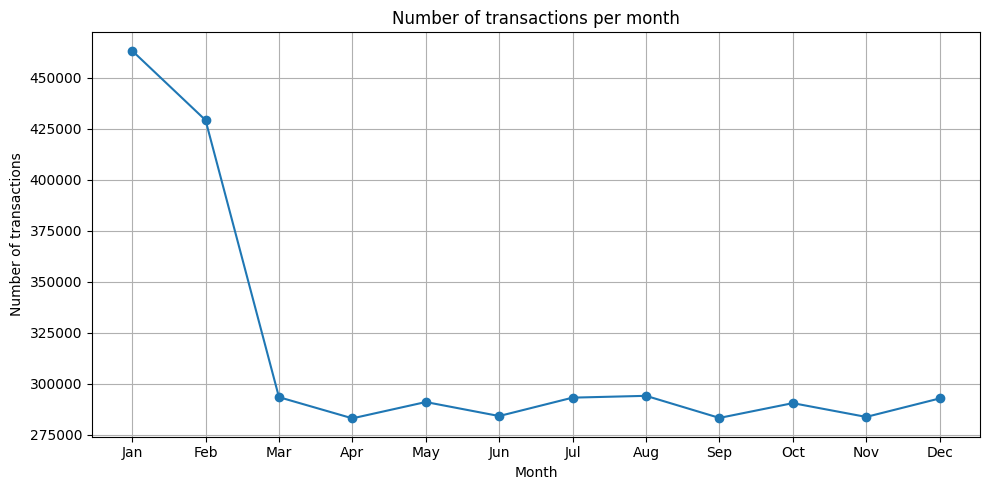

In [42]:

plt.figure(figsize=(10, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.title('Number of transactions per month')
plt.xlabel('Month')
plt.ylabel('Number of transactions')
plt.grid(True)
plt.tight_layout()
plt.show()


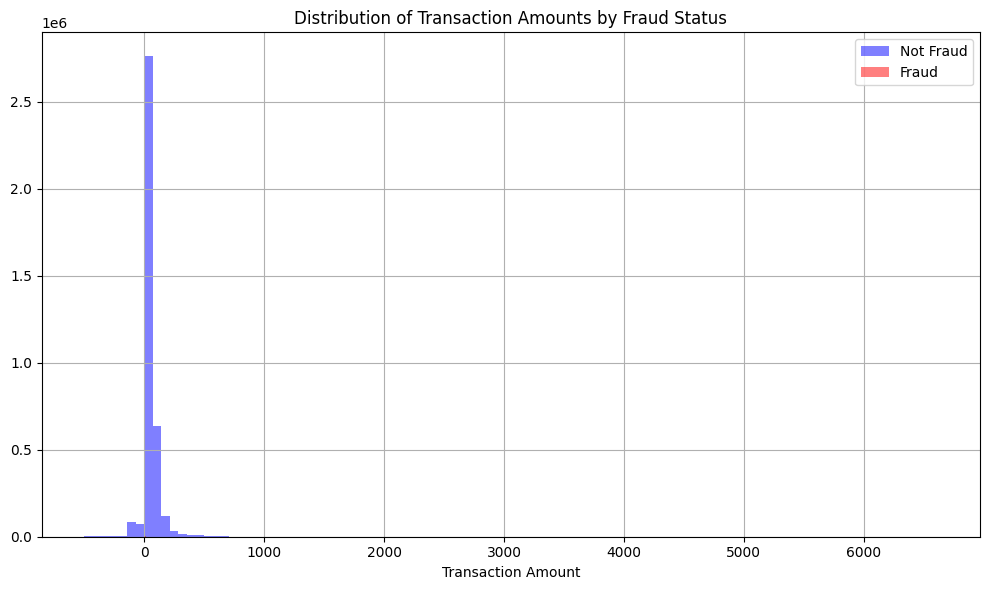

In [63]:


# Separate the Amounts based on fraud status
fraudulent = transactions[transactions['Is Fraud?'] == 1]['Amount']
non_fraudulent = transactions[transactions['Is Fraud?'] == 0]['Amount']


plt.figure(figsize=(10, 6))
plt.hist(non_fraudulent, bins=100, color='blue', alpha=0.5, label='Not Fraud')
plt.hist(fraudulent, bins=100, color='red', alpha=0.5, label='Fraud')

plt.xlabel('Transaction Amount')
plt.title('Distribution of Transaction Amounts by Fraud Status')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The fraudulent cases are not visible from this plot, lets create separate plot for non-fraudulent and fraudulent cases.

<ipython-input-61-b410b4bc45a9>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


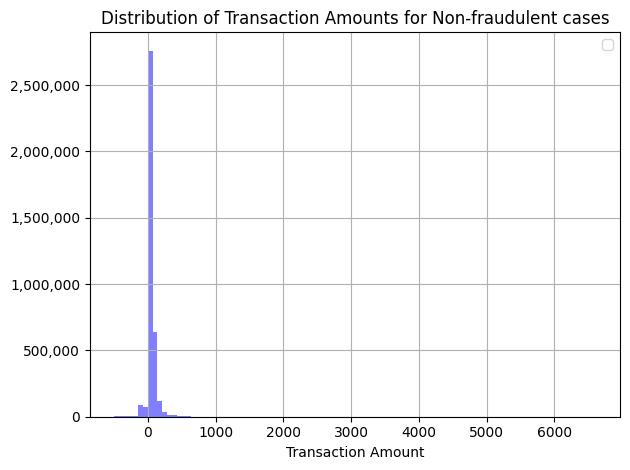

In [61]:
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.hist(non_fraudulent, bins=100, color='blue', alpha=0.5)
plt.xlabel('Transaction Amount')
plt.title('Distribution of Transaction Amounts for Non-fraudulent cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-58-de1908b4dfe2>:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


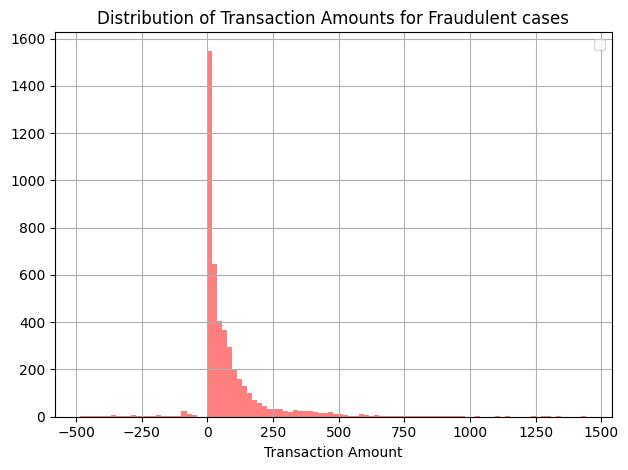

In [58]:
plt.hist(fraudulent, bins=100, color='red', alpha=0.5)
plt.xlabel('Transaction Amount')
plt.title('Distribution of Transaction Amounts for Fraudulent cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It is apparent that the y axis spans over far greater values for the non-fraudulent cases as compared to the fraudulent cases. This is not surprising, since the fraudulent cases are significantly rarer. Nevertheless, we may care to compare the shapes of the distributions rather than the raw counts (which we know are very different). To do this, we can set the density parameter to True.

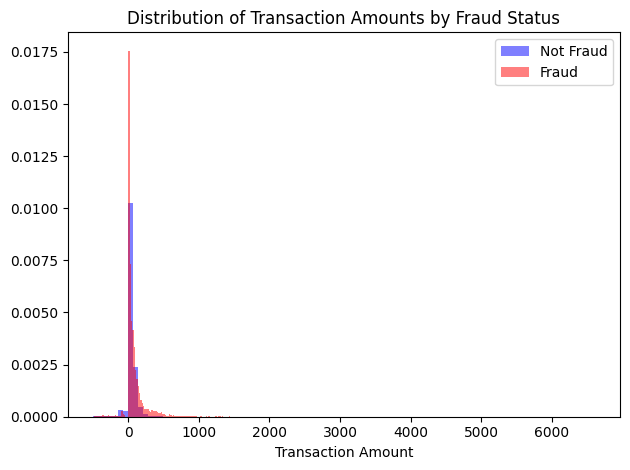

In [67]:
plt.hist(non_fraudulent, bins=100, alpha=0.5, label='Not Fraud', color='blue', density=True)
plt.hist(fraudulent, bins=100, alpha=0.5, label='Fraud', color='red', density=True)
plt.xlabel('Transaction Amount')
plt.title('Distribution of Transaction Amounts by Fraud Status')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

We can observe that the distribution of the fraudulent cases tends to be more right skewed- more transactions with larger amounts tend to appear.

##Finding a column with different distribution for fraud and non-fraud transactions

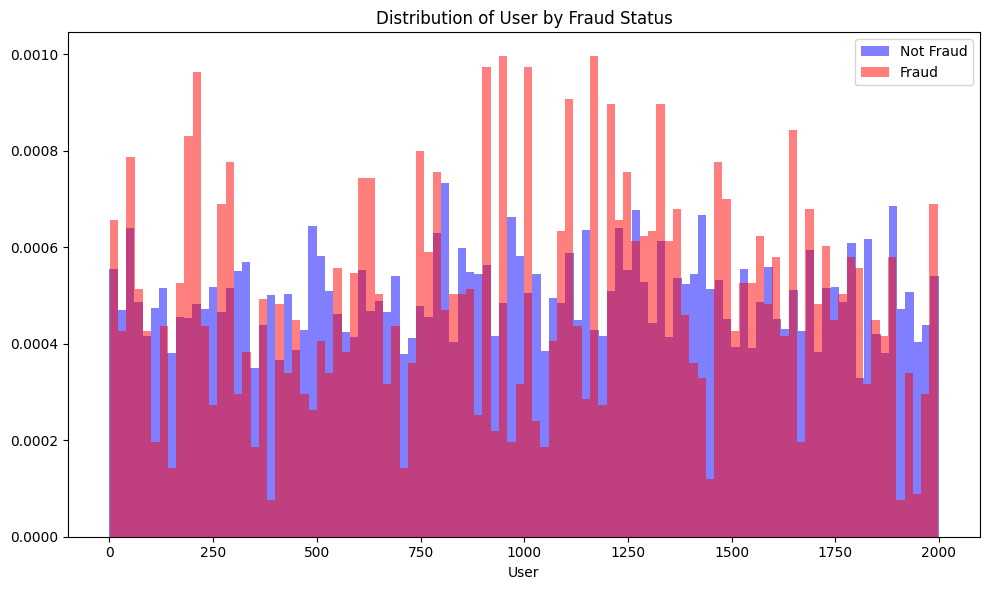

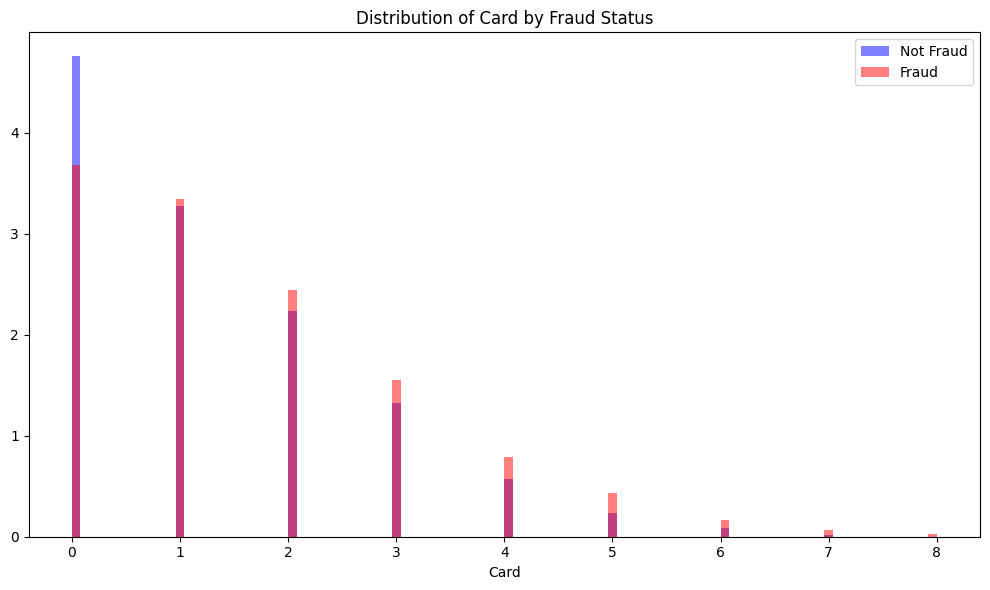

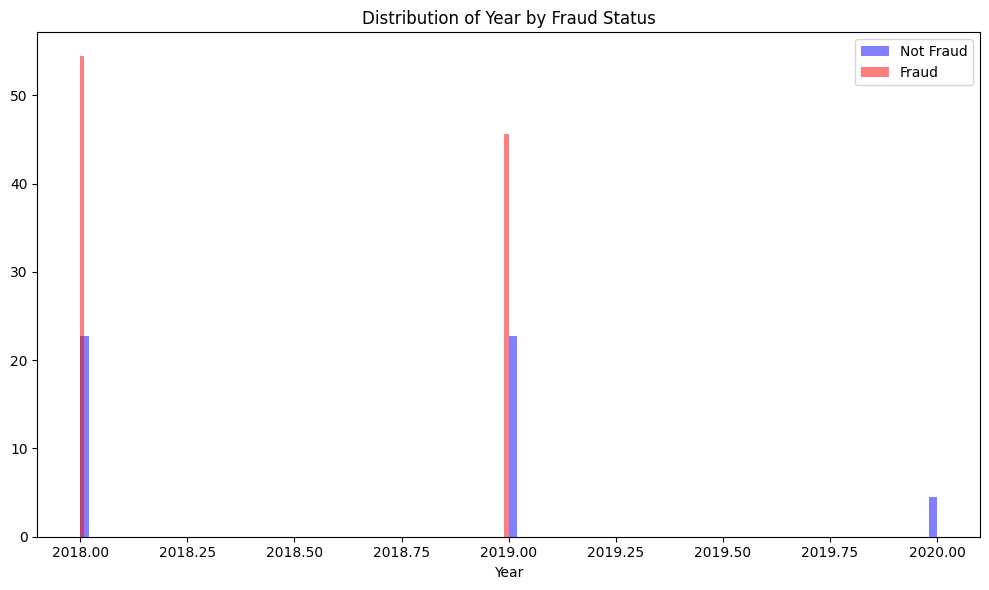

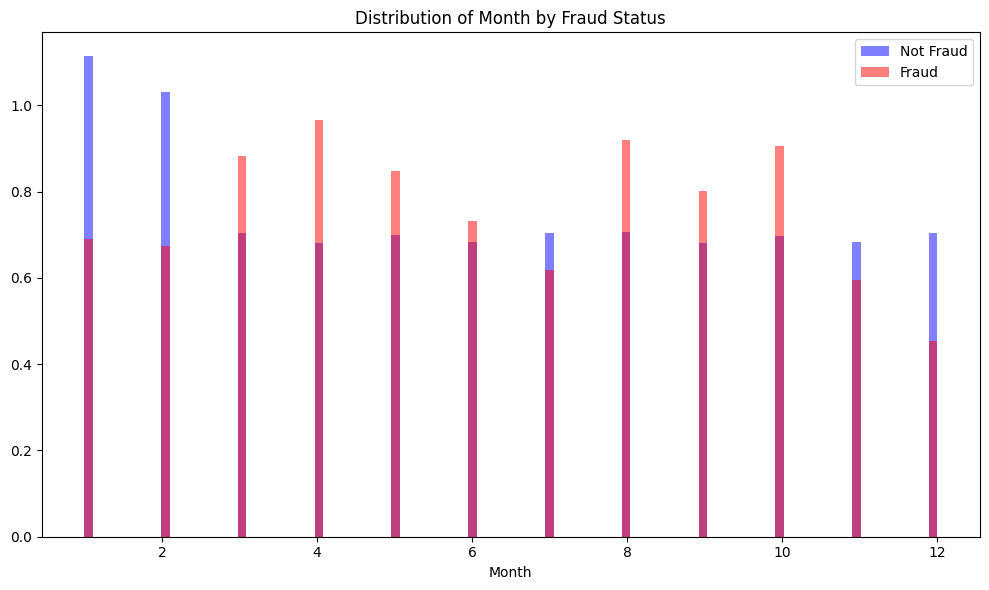

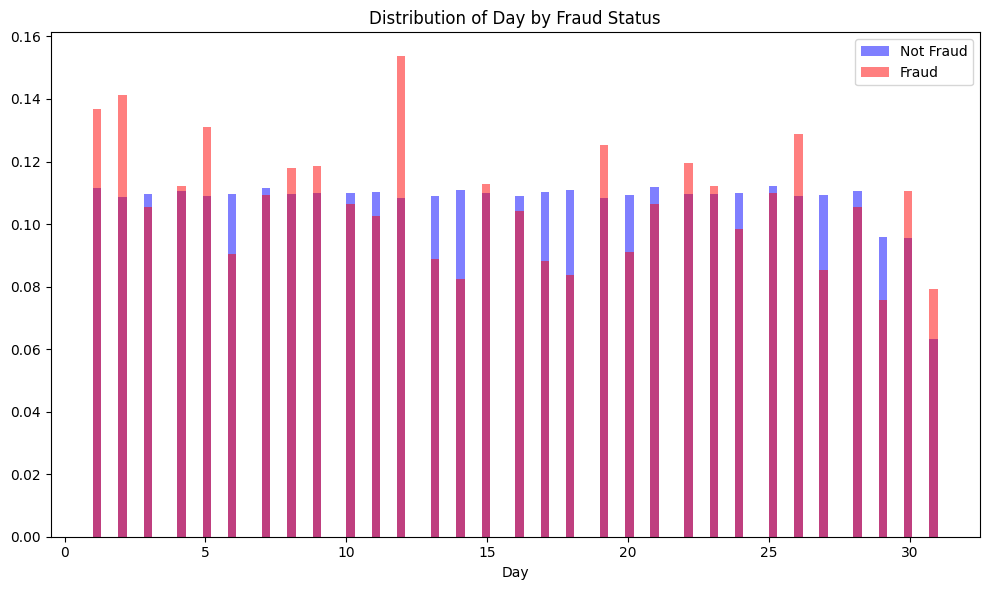

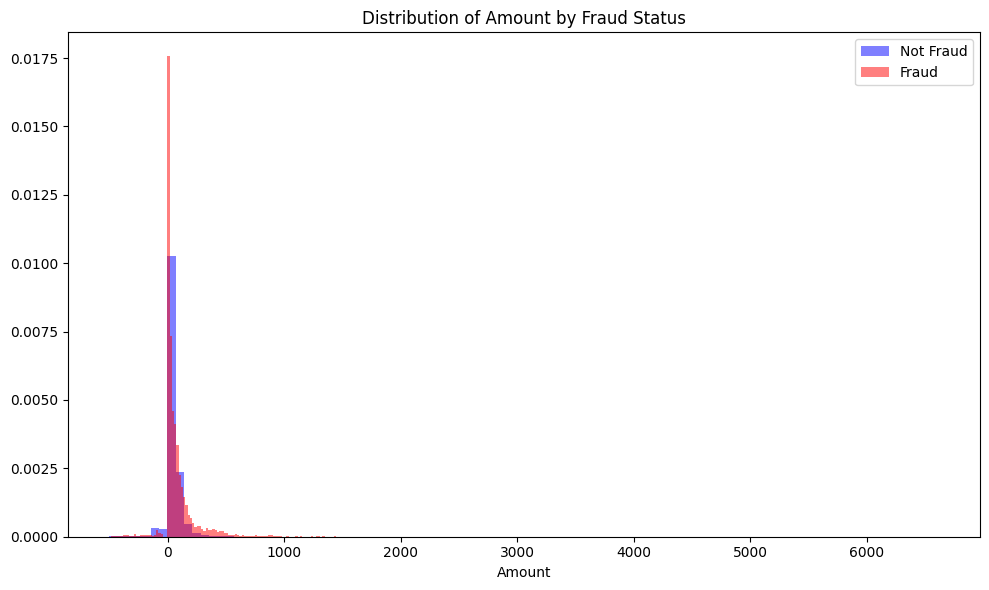

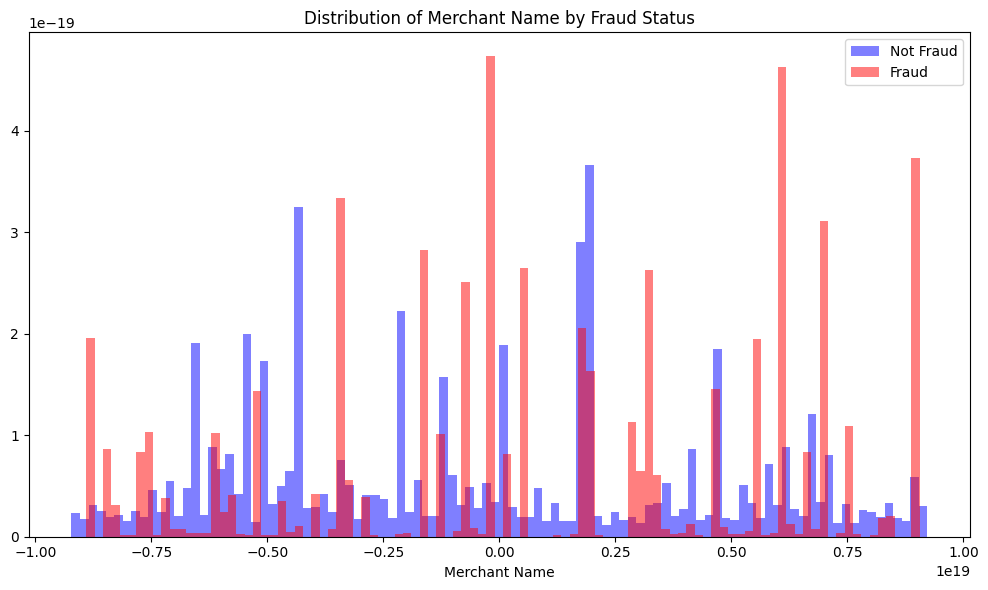

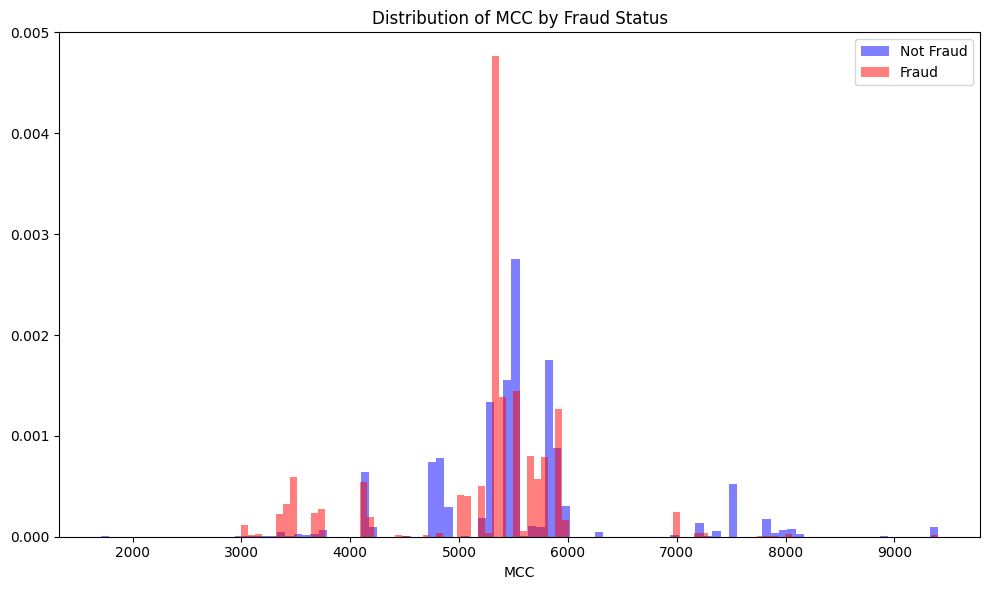

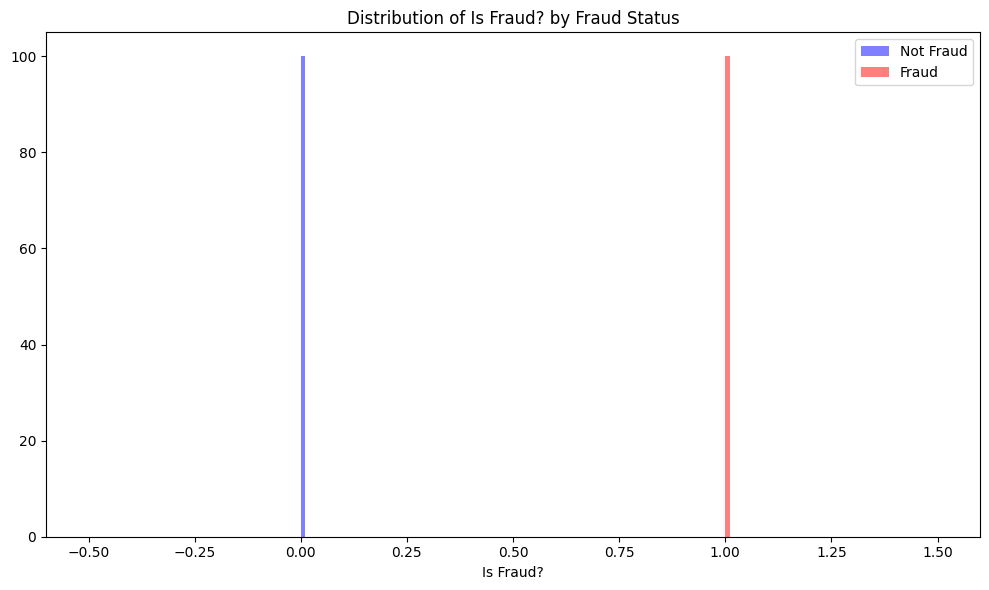

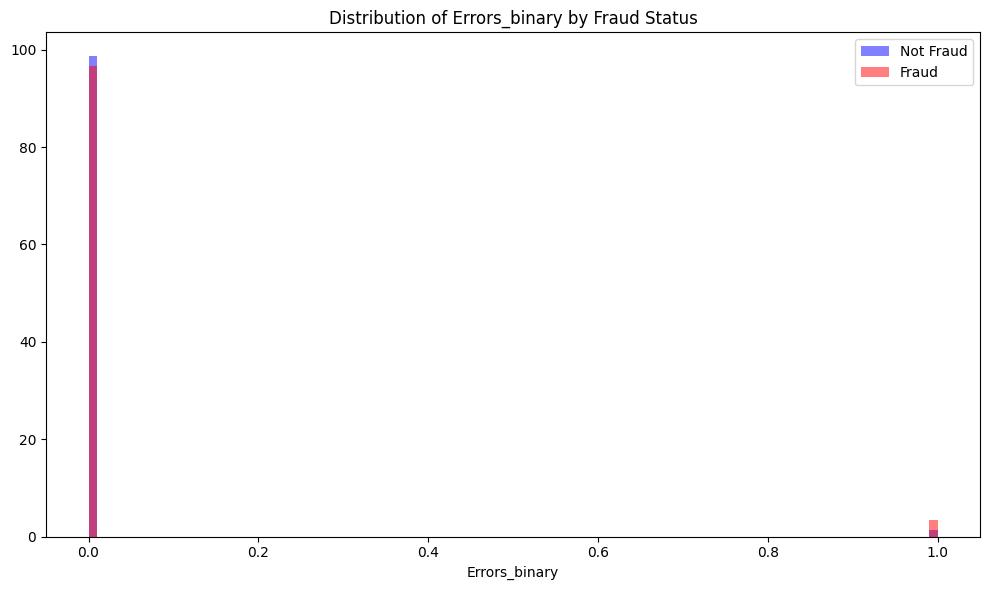

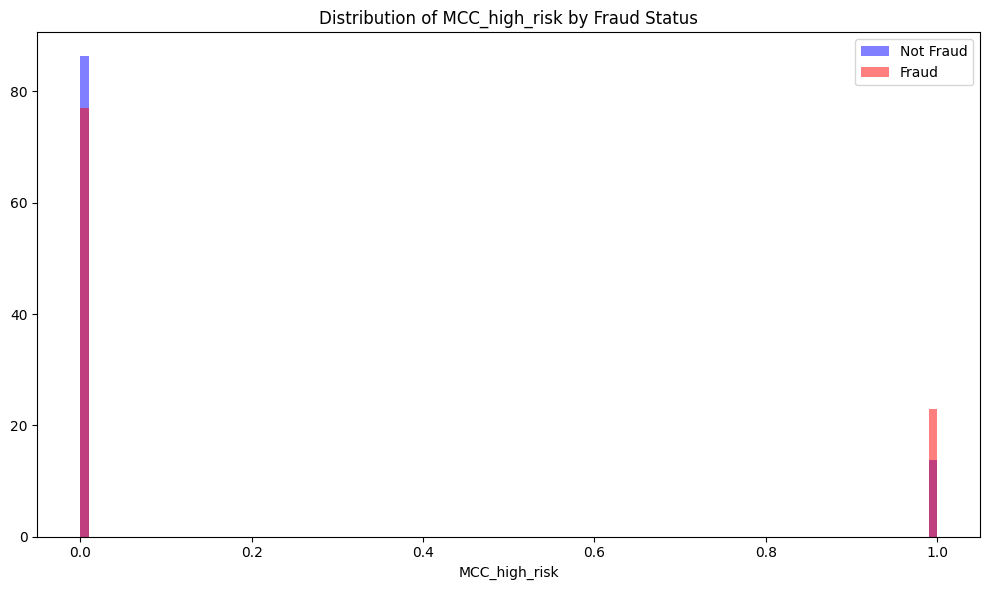

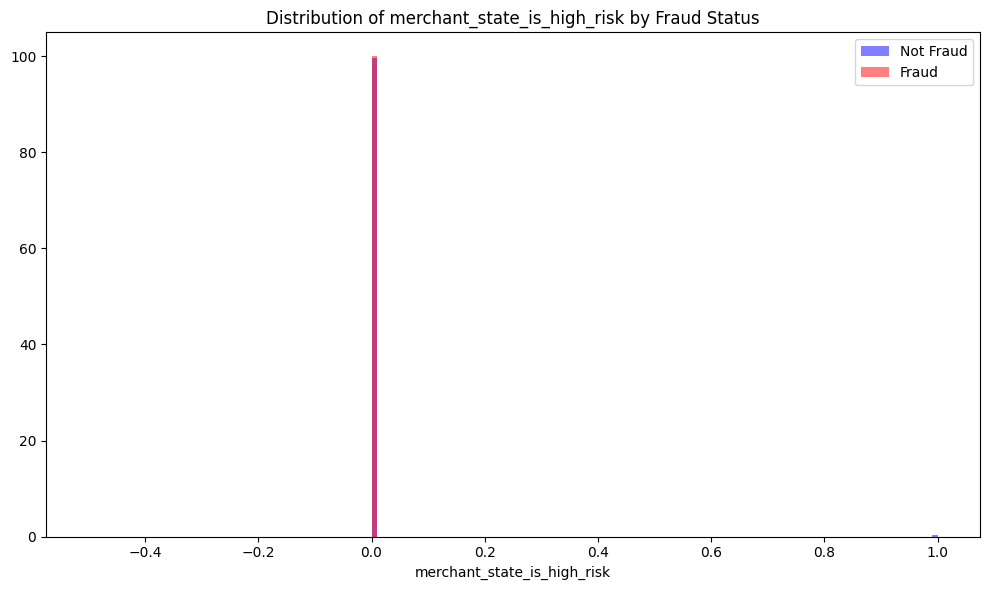

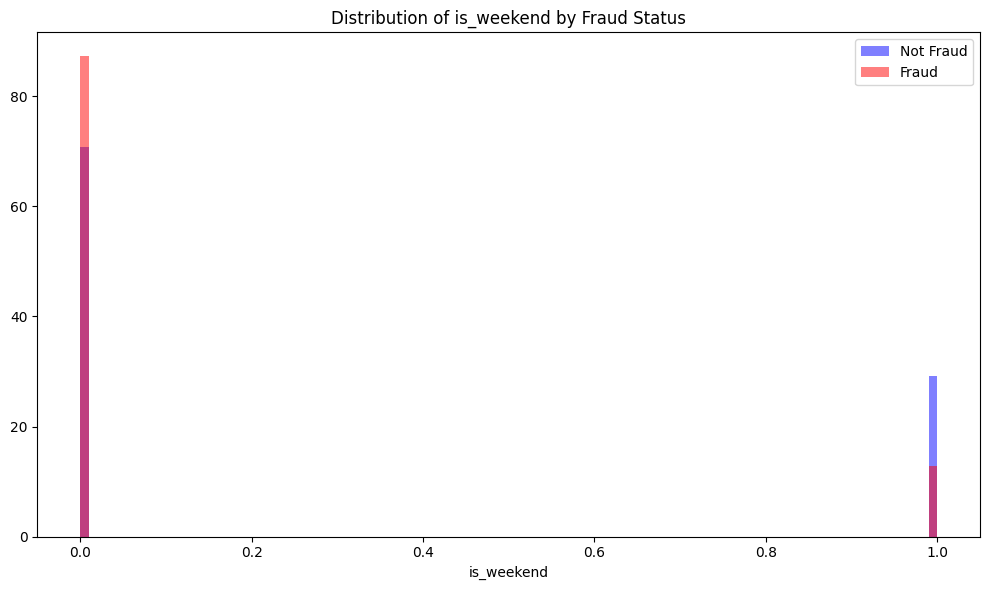

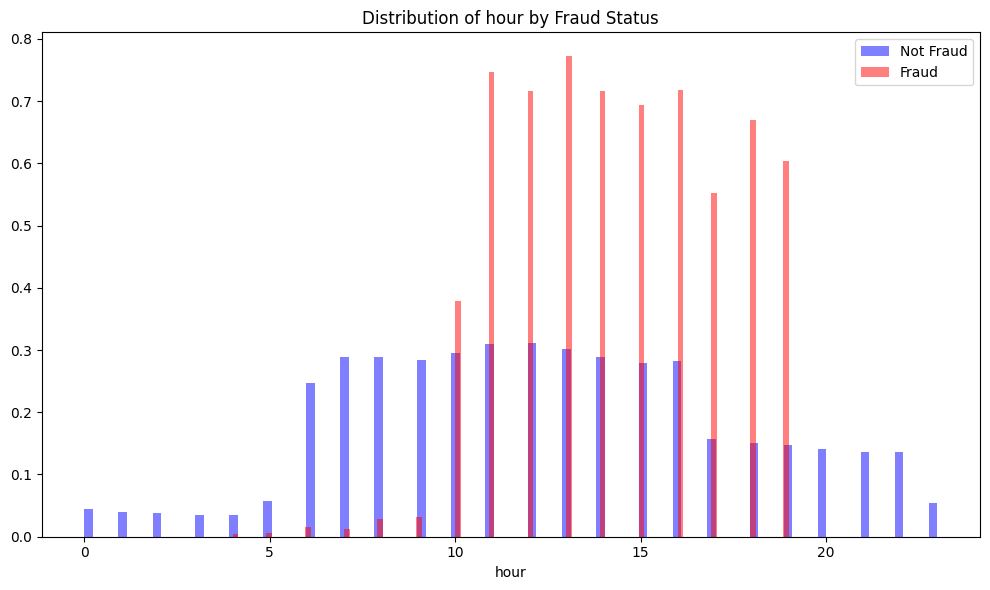

In [72]:
for variable in transactions.select_dtypes(include=['number']).columns.tolist():
  # Separate the Amounts based on fraud status
  fraudulent = transactions[transactions['Is Fraud?'] == 1][variable]
  non_fraudulent = transactions[transactions['Is Fraud?'] == 0][variable]


  plt.figure(figsize=(10, 6))
  plt.hist(non_fraudulent, bins=100, alpha=0.5, label='Not Fraud', color='blue', density=True)
  plt.hist(fraudulent, bins=100, alpha=0.5, label='Fraud', color='red', density=True)

  plt.xlabel(variable)
  plt.legend()
  plt.title(f'Distribution of {variable} by Fraud Status')
  plt.grid(False)
  plt.tight_layout()
  plt.show()

Some variables do have a different distribution for the fraudulent and non-fraudulent cases. For instance, it appears that frauds tend happen more on weekdays and be marked with a high risk MCC. Nevertheless, the most striking is the difference in distributions for the variable Amount.

##Adressing the points from task 3 (at least to the extent that is possible without the data being joined)

I have already performed some feature etraction in the code so far, the hour the transaction has been made. Nevertheless, the floating mean / sum variable and the first occurrence are not possible to be extracted without joining the data, which, unfortunately, I didnt manage to do. However, I include the following code, showing how I would do it if I managed to join the data.

###floating mean over the last 30 transactions

I tried to work with what I had in transaction dataset itself. In the joined datasets, we would want to calculate the floating average over the last 30 days with respect to each account (which I assume is denoted by the variable Card Number). Just to demonstrate how I would do it on the joined dataset, I enclose the code below. For the demonstration purpose, I show how I would calculate the floating average not with respect to the Card Number, but with respect to some variable which is present in the transactions dataset (I chose MCC, but it does not matter). To perfom it on the joined dataset, it would only be necessary to replace column "MCC" with "Card Number".

In [78]:


transactions = transactions.sort_values(by=['MCC', 'Date'])


transactions = (
    transactions
    .groupby('MCC', group_keys=False)
    .apply(lambda group: group.assign(
        amount_30d_avg=group.rolling('30D', on='Date')['Amount'].mean()
    ))
)


<ipython-input-78-e1988f9bda0f>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(


In [79]:
display(transactions)

,User,Card,Year,Month,Day,Time,Amount,Merchant Name,Merchant City,Merchant State,...,MCC_desc,MCC_high_risk,merchant_state_is_high_risk,use_chip_Chip Transaction,use_chip_Online Transaction,use_chip_Swipe Transaction,Date,is_weekend,hour,amount_30d_avg
3769373,1995,1,2018,1,2,06:45:00,71.16,-4136279596029894102,Freeport,New York (US),...,"Air Conditioning, Heating and Plumbing Contrac...",0,0,True,False,False,2018-01-02,0,6,71.16
3233670,1705,2,2018,1,2,14:46:00,148.72,-1423635972834615381,Massillon,Ohio (US),...,"Air Conditioning, Heating and Plumbing Contrac...",0,0,True,False,False,2018-01-02,0,14,109.94
3049469,1601,3,2018,1,3,09:17:00,121.89,8647565168813467064,Fayetteville,North Carolina (US),...,"Air Conditioning, Heating and Plumbing Contrac...",0,0,True,False,False,2018-01-03,0,9,113.92
2703651,1420,1,2018,1,3,11:42:00,202.17,-2394095345121070089,Schenectady,New York (US),...,"Air Conditioning, Heating and Plumbing Contrac...",0,0,True,False,False,2018-01-03,0,11,135.99
3753403,1986,0,2018,1,3,13:27:00,100.61,-6849686704036984046,Knoxville,Tennessee (US),...,"Air Conditioning, Heating and Plumbing Contrac...",0,0,True,False,False,2018-01-03,0,13,128.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3070703,1613,0,2020,2,28,15:40:00,13.34,6135208568923449408,Mesa,Arizona (US),...,Postal Services—Government Only,0,0,False,False,True,2020-02-28,0,15,14.93
89583,44,2,2020,2,28,16:11:00,16.50,6135208568923449408,Port Orange,Florida (US),...,Postal Services—Government Only,0,0,True,False,False,2020-02-28,0,16,14.93
235768,123,0,2020,2,28,16:30:00,17.35,6135208568923449408,Madison,Wisconsin (US),...,Postal Services—Government Only,0,0,False,False,True,2020-02-28,0,16,14.93
2974216,1563,0,2020,2,28,16:37:00,20.13,6135208568923449408,Suwanee,Georgia (US),...,Postal Services—Government Only,0,0,True,False,False,2020-02-28,0,16,14.93


In [ ]:

transactions_full = transactions_full.sort_values(by=['Card Number', 'Date'])


transactions_full = (
    transactions_full
    .groupby('Card Number', group_keys=False)
    .apply(lambda group: group.assign(
        amount_30d_avg=group.rolling('30D', on='Date')['Amount'].mean()
    ))
)


NameError: name 'transactions_full' is not defined

###floating mean over the last 30 days

The same approach as above.

In [81]:
transactions['transaction_datetime'] = pd.to_datetime(
    transactions['Date'].astype(str) + ' ' + transactions['Time'].astype(str)
)


In [84]:
# Sort transactions within each card by time
transactions = transactions.sort_values(by=['MCC', 'transaction_datetime'])

# Compute rolling average over the last 30 transactions for each card
transactions= (
    transactions
    .groupby('MCC', group_keys=False)
    .apply(lambda group: group.assign(
        amount_30tx_avg=group['Amount'].rolling(window=30, min_periods=1).mean()
    ))
)


<ipython-input-84-764dd20fc6f0>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(


In [85]:
display(transactions)

,User,Card,Year,Month,Day,Time,Amount,Merchant Name,Merchant City,Merchant State,...,merchant_state_is_high_risk,use_chip_Chip Transaction,use_chip_Online Transaction,use_chip_Swipe Transaction,Date,is_weekend,hour,amount_30d_avg,transaction_datetime,amount_30tx_avg
3769373,1995,1,2018,1,2,06:45:00,71.16,-4136279596029894102,Freeport,New York (US),...,0,True,False,False,2018-01-02,0,6,71.16,2018-01-02 06:45:00,71.16
3233670,1705,2,2018,1,2,14:46:00,148.72,-1423635972834615381,Massillon,Ohio (US),...,0,True,False,False,2018-01-02,0,14,109.94,2018-01-02 14:46:00,109.94
3049469,1601,3,2018,1,3,09:17:00,121.89,8647565168813467064,Fayetteville,North Carolina (US),...,0,True,False,False,2018-01-03,0,9,113.92,2018-01-03 09:17:00,113.92
2703651,1420,1,2018,1,3,11:42:00,202.17,-2394095345121070089,Schenectady,New York (US),...,0,True,False,False,2018-01-03,0,11,135.99,2018-01-03 11:42:00,135.99
3753403,1986,0,2018,1,3,13:27:00,100.61,-6849686704036984046,Knoxville,Tennessee (US),...,0,True,False,False,2018-01-03,0,13,128.91,2018-01-03 13:27:00,128.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3070703,1613,0,2020,2,28,15:40:00,13.34,6135208568923449408,Mesa,Arizona (US),...,0,False,False,True,2020-02-28,0,15,14.93,2020-02-28 15:40:00,14.07
89583,44,2,2020,2,28,16:11:00,16.50,6135208568923449408,Port Orange,Florida (US),...,0,True,False,False,2020-02-28,0,16,14.93,2020-02-28 16:11:00,14.09
235768,123,0,2020,2,28,16:30:00,17.35,6135208568923449408,Madison,Wisconsin (US),...,0,False,False,True,2020-02-28,0,16,14.93,2020-02-28 16:30:00,14.02
2974216,1563,0,2020,2,28,16:37:00,20.13,6135208568923449408,Suwanee,Georgia (US),...,0,True,False,False,2020-02-28,0,16,14.93,2020-02-28 16:37:00,14.31


In [ ]:
# Sort transactions within each card by time
transactions_full = transactions_full.sort_values(by=['Card Number', 'transaction_datetime'])

# Compute rolling average over the last 30 transactions for each card
transactions_full= (
    transactions_full
    .groupby('Card Number', group_keys=False)
    .apply(lambda group: group.assign(
        amount_30tx_avg=group['Amount'].rolling(window=30, min_periods=1).mean()
    ))
)


NameError: name 'transactions_full' is not defined

###first occurence

Same approach as above

In [92]:
transactions = transactions.sort_values(by=['MCC', 'transaction_datetime'])

merchant_first_time = (
    transactions
    .groupby('MCC')['Merchant Name']
    .apply(lambda x: (~x.duplicated()).astype(int))
    .reset_index(level=0, drop=True)
)

transactions['merchant_first_time'] = merchant_first_time


In [90]:
display(transactions)

,User,Card,Year,Month,Day,Time,Amount,Merchant Name,Merchant City,Merchant State,...,use_chip_Chip Transaction,use_chip_Online Transaction,use_chip_Swipe Transaction,Date,is_weekend,hour,amount_30d_avg,transaction_datetime,amount_30tx_avg,merchant_first_time
3769373,1995,1,2018,1,2,06:45:00,71.16,-4136279596029894102,Freeport,New York (US),...,True,False,False,2018-01-02,0,6,71.16,2018-01-02 06:45:00,71.16,1
3233670,1705,2,2018,1,2,14:46:00,148.72,-1423635972834615381,Massillon,Ohio (US),...,True,False,False,2018-01-02,0,14,109.94,2018-01-02 14:46:00,109.94,1
3049469,1601,3,2018,1,3,09:17:00,121.89,8647565168813467064,Fayetteville,North Carolina (US),...,True,False,False,2018-01-03,0,9,113.92,2018-01-03 09:17:00,113.92,1
2703651,1420,1,2018,1,3,11:42:00,202.17,-2394095345121070089,Schenectady,New York (US),...,True,False,False,2018-01-03,0,11,135.99,2018-01-03 11:42:00,135.99,1
3753403,1986,0,2018,1,3,13:27:00,100.61,-6849686704036984046,Knoxville,Tennessee (US),...,True,False,False,2018-01-03,0,13,128.91,2018-01-03 13:27:00,128.91,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3070703,1613,0,2020,2,28,15:40:00,13.34,6135208568923449408,Mesa,Arizona (US),...,False,False,True,2020-02-28,0,15,14.93,2020-02-28 15:40:00,14.07,0
89583,44,2,2020,2,28,16:11:00,16.50,6135208568923449408,Port Orange,Florida (US),...,True,False,False,2020-02-28,0,16,14.93,2020-02-28 16:11:00,14.09,0
235768,123,0,2020,2,28,16:30:00,17.35,6135208568923449408,Madison,Wisconsin (US),...,False,False,True,2020-02-28,0,16,14.93,2020-02-28 16:30:00,14.02,0
2974216,1563,0,2020,2,28,16:37:00,20.13,6135208568923449408,Suwanee,Georgia (US),...,True,False,False,2020-02-28,0,16,14.93,2020-02-28 16:37:00,14.31,0


In [ ]:
transactions_full = transactions_full.sort_values(by=['Card Number', 'transaction_datetime'])

merchant_first_time = (
    transactions_full
    .groupby('Card Number')['Merchant Name']
    .apply(lambda x: (~x.duplicated()).astype(int))
    .reset_index(level=0, drop=True)
)

transactions_full['merchant_first_time'] = merchant_first_time

NameError: name 'transactions_full' is not defined

#Training the model

Due to the fact that I was unable to join the datasets, I will train the models on the transactions dataset only. The steps in case of using the full joined dataset would be similar.

In [83]:
# Train-test split
train_df = transactions[transactions['Date'] <= '2019-10-01']
test_df = transactions[transactions['Date'] > '2019-10-01']

In [84]:
features = transactions_features
target = 'Is Fraud?'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]


In [85]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:09:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [86]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    765627
           1       0.00      0.00      0.00       260

    accuracy                           1.00    765887
   macro avg       0.50      0.50      0.50    765887
weighted avg       1.00      1.00      1.00    765887

AUC: 0.8478322844695113


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


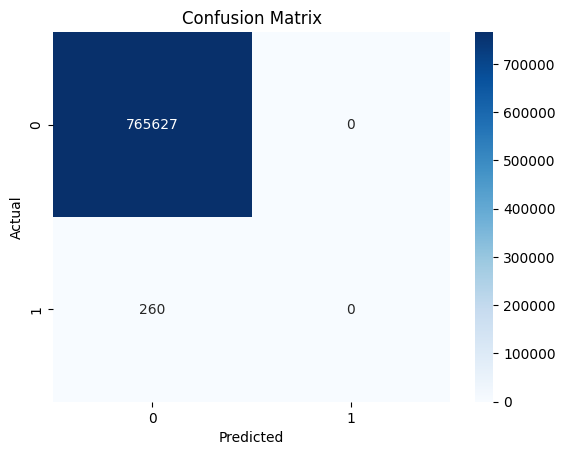

In [87]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [88]:
event_rate=transactions['Is Fraud?'].mean()
print(event_rate)

0.0012104536874549352


In [89]:
event_rate_test=test_df['Is Fraud?'].mean()
print(event_rate_test)

0.0003394756667759082


In [90]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")

print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred, zero_division=0):.6f}")

Accuracy: 0.999661
Precision: 0.000000
F1 score: 0.000000


The model did not manage to capture any of the positive cases- in fact, no observation has been classified as positive. This is because the dataset suffers from severe class imbalance - only 0.12% of positive cases and thus it is difficult for the model to learn the patterns for the positive class.

We also encounter a classical problem with imbalanced datasets - a very high accuracy. The high accuracy can be misleading, because at first glance it may appear that the model has a good performance. In actuality, since the accuracy measures the proportion of correctly classified observations, the model can achieve a very high accuracy just by classifying all the observations as 0 (our case). Such model would not be useful at all, since it would completely fail at identifying the class of interest.
Likewise, the ROC AUC may be misleading, too. Since it measures how well the model ranks positive cases relative to negative ones and thus it evaluates the probability that a randomly chosen fraud will get a higher predicted score than a non-fraud, even if our model predicts all labels as 0, but still gives slightly higher probabilities to actual fraud cases, the AUC can be high (as in our case).

For imbalanced datasets, therefore, it is advisable to look at precision and recall, but not on their own. Each of these metrics can be "fooled" in extreme cases.

Precision tells us how many of the observations that the models has labelled as 1 were actually positive. Recall tells us how many of the actual positive the model managed to identify. To "fool" precision, it is enough for the model to classify one observation it is very "sure about" as 1 and precision will be 1, even if the model misclassified all the rest of the positive cases. However, in such case, recall would be very low, as very small proportion of the actual positives would be identifyed by the model. Recall be "fooled" by labelling all the observations as positives. In this case, however, the precision would be very low, since out of all the observations the model labelled as positive, only few actually were.

Therefore, a good model manages to balance these two metrics - ideally, it has large precision as well as large recall. For this, we use the F1 score - a metric, that is actually a harmonious mean of precision and recall and which is high (close to 1) only if both of these measures are high. Since our F1 score is 0, it is clear that the model performs poorly.

There are certain approaches that can be employed when working with imbalanced datasets, such as undersampling the positive class, oversampling the negative class, adjusting weights or SMOTE.

Nevertheless, since we have high ROC AUC, it suggests that the model gives higher probability to fraudulent cases. Lets lower the classification threshold and see if it helps.

In [91]:


threshold = 0.001
y_pred_adjusted = (y_proba >= threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted, zero_division=0))

[[447861 317766]
 [    17    243]]
              precision    recall  f1-score   support

           0       1.00      0.58      0.74    765627
           1       0.00      0.93      0.00       260

    accuracy                           0.59    765887
   macro avg       0.50      0.76      0.37    765887
weighted avg       1.00      0.59      0.74    765887



In [92]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_adjusted):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_adjusted, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_adjusted, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_adjusted, zero_division=0):.6f}")

Accuracy: 0.585078
Precision: 0.000764
F1 score: 0.001527


Only with extremely small threshold the results started to get a little better. Lets try other methods.



###Undersampling

Undersampling - reduces the number of majority class. It is fast but we lose a lot of data - can negatively affect performance.

In [93]:
# Separate majority and minority classes
majority = train_df[train_df['Is Fraud?'] == 0]
minority = train_df[train_df['Is Fraud?'] == 1]

# Downsample majority class
majority_downsampled = resample(majority,
                                replace=False,
                                n_samples=len(minority),
                                random_state=42)

# Combine minority with downsampled majority
train_downsampled = pd.concat([majority_downsampled, minority])

# Shuffle the dataset
train_downsampled = train_downsampled.sample(frac=1, random_state=42)


In [94]:

X_train_down = train_downsampled[features]
y_train_down = train_downsampled[target]
X_test_down = test_df[features]
y_test_down = test_df[target]

model_down = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_down.fit(X_train_down, y_train_down)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:10:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [95]:
y_pred_down = model_down.predict(X_test)
y_proba_down = model_down.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_down))
print("AUC:", roc_auc_score(y_test, y_proba_down))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81    765627
           1       0.00      0.82      0.00       260

    accuracy                           0.69    765887
   macro avg       0.50      0.75      0.41    765887
weighted avg       1.00      0.69      0.81    765887

AUC: 0.8478410932377094


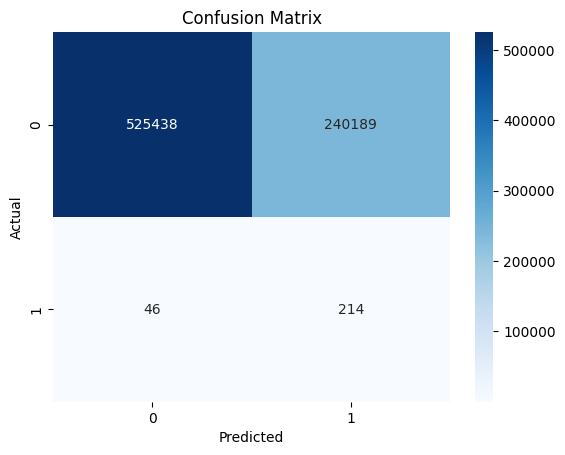

In [96]:
cm_down = confusion_matrix(y_test, y_pred_down)
sns.heatmap(cm_down, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [97]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_down):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_down, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_down, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_down, zero_division=0):.6f}")

Accuracy: 0.686331
Precision: 0.000890
F1 score: 0.001778


The results are far better than before applying downsampling. Lets try to lower the threshold to see if they improve.

In [98]:
threshold = 0.2
y_pred_down_adjusted = (y_proba_down >= threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_pred_down_adjusted))
print(classification_report(y_test, y_pred_down_adjusted, zero_division=0))

[[376389 389238]
 [     1    259]]
              precision    recall  f1-score   support

           0       1.00      0.49      0.66    765627
           1       0.00      1.00      0.00       260

    accuracy                           0.49    765887
   macro avg       0.50      0.74      0.33    765887
weighted avg       1.00      0.49      0.66    765887



In [99]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_down_adjusted):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_down_adjusted, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_down_adjusted, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_down_adjusted, zero_division=0):.6f}")

Accuracy: 0.491780
Precision: 0.000665
F1 score: 0.001329


Surprisingly, with lower thresholds, the F1-score is actually worse. Lets try with upsampling the positive class. It may cause the model to overfit to the class 0, but since our model is very bad at identifying it, is probably worth a try.

##Oversampling

In [100]:
minority_upsampled = resample(minority,
                              replace=True,
                              n_samples=len(majority),
                              random_state=42)

train_upsampled = pd.concat([majority, minority_upsampled])
train_upsampled = train_upsampled.sample(frac=1, random_state=42)

In [101]:

X_train_up = train_upsampled[features]
y_train_up = train_upsampled[target]
X_test_up = test_df[features]
y_test_up = test_df[target]

model_up = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_up.fit(X_train_up, y_train_up)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:10:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [102]:
y_pred_up = model_up.predict(X_test)
y_proba_up = model_up.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_up))
print("AUC:", roc_auc_score(y_test, y_proba_up))

              precision    recall  f1-score   support

           0       1.00      0.70      0.82    765627
           1       0.00      0.82      0.00       260

    accuracy                           0.70    765887
   macro avg       0.50      0.76      0.41    765887
weighted avg       1.00      0.70      0.82    765887

AUC: 0.85340498451194


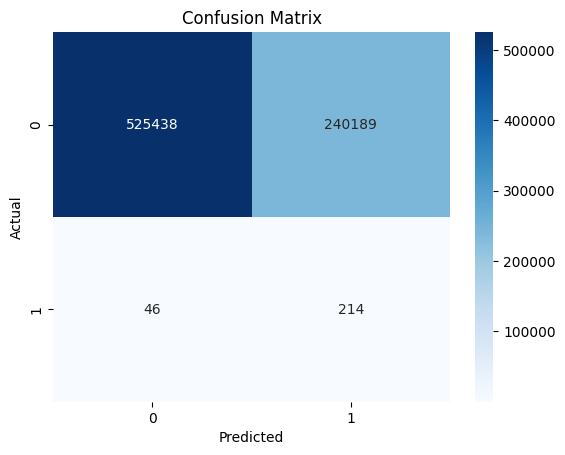

In [103]:
cm_up = confusion_matrix(y_test, y_pred_down)
sns.heatmap(cm_up, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [104]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_up):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_up, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_up, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_up, zero_division=0):.6f}")

Accuracy: 0.700393
Precision: 0.000928
F1 score: 0.001853


The F1 score is slightly better as with downsampling. Lets try to lower the classification threshold.

In [105]:
threshold = 0.4
y_pred_up_adjusted = (y_proba_up >= threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_pred_up_adjusted))
print(classification_report(y_test, y_pred_up_adjusted, zero_division=0))

[[468493 297134]
 [    23    237]]
              precision    recall  f1-score   support

           0       1.00      0.61      0.76    765627
           1       0.00      0.91      0.00       260

    accuracy                           0.61    765887
   macro avg       0.50      0.76      0.38    765887
weighted avg       1.00      0.61      0.76    765887



In [106]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_up_adjusted):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_up_adjusted, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_up_adjusted, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_up_adjusted, zero_division=0):.6f}")

Accuracy: 0.612009
Precision: 0.000797
F1 score: 0.001593


The F1 score gets worse with lower thresholds, again. Lets try SMOTE.

##SMOTE

In [107]:
X = train_df[features]
y = train_df['Is Fraud?']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


In [108]:
train_df_smote = pd.concat([X_smote, y_smote], axis=1)

In [109]:

X_train_smote = train_df_smote[features]
y_train_smote = train_df_smote[target]
X_test_smote = test_df[features]
y_test_smote = test_df[target]

model_smote = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_smote.fit(X_train_smote, y_train_smote)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:10:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [110]:
y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("AUC:", roc_auc_score(y_test, y_proba_smote))

              precision    recall  f1-score   support

           0       1.00      0.74      0.85    765627
           1       0.00      0.70      0.00       260

    accuracy                           0.74    765887
   macro avg       0.50      0.72      0.43    765887
weighted avg       1.00      0.74      0.85    765887

AUC: 0.824911033199436


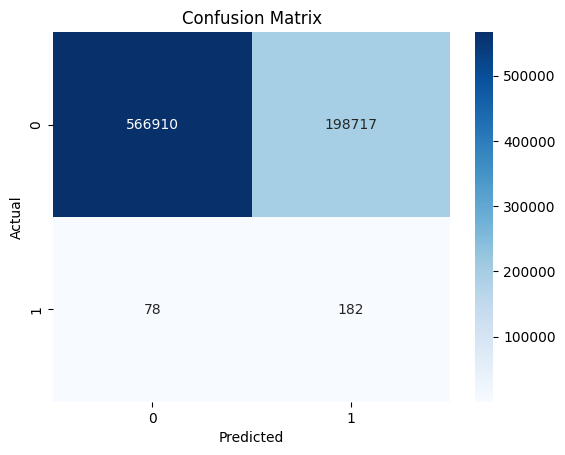

In [111]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [112]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.6f}")

print(f"Precision: {precision_score(y_test, y_pred_smote, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_pred_smote, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_pred_smote, zero_division=0):.6f}")

Accuracy: 0.740438
Precision: 0.000915
F1 score: 0.001828


The F1 score is very similar as with undersampling and oversampling. Lets see if it improves with lower classification threshold.

In [113]:
threshold = 0.2
y_proba_smote_adjusted = (y_proba_smote >= threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_proba_smote_adjusted))
print(classification_report(y_test, y_proba_smote_adjusted, zero_division=0))

[[477682 287945]
 [    39    221]]
              precision    recall  f1-score   support

           0       1.00      0.62      0.77    765627
           1       0.00      0.85      0.00       260

    accuracy                           0.62    765887
   macro avg       0.50      0.74      0.38    765887
weighted avg       1.00      0.62      0.77    765887



In [114]:
print(f"Accuracy: {accuracy_score(y_test, y_proba_smote_adjusted):.6f}")

print(f"Precision: {precision_score(y_test, y_proba_smote_adjusted, zero_division=0):.6f}")

print(f"Recall: {recall_score(y_test, y_proba_smote_adjusted, zero_division=0):.6f}")

print(f"F1 score: {f1_score(y_test, y_proba_smote_adjusted, zero_division=0):.6f}")

Accuracy: 0.623986
Precision: 0.000767
F1 score: 0.001532


As in previous cases, the F1 score actually worsened.

So far, oversampling proved as the most efficient method based on the F1 score. Therefore, we can try hyperparameter tuning on this method.

###Hyperparameter tuning

In [ ]:

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'gamma': [0, 1, 5]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=model_up,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

#Fit on upsampled data
grid_search.fit(X_train_up, y_train_up)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Unfortunately, the session collapsed after a few minutes due to insufficient RAM capacity. Nevertheless, this is how I would perform hyperparameter tuning.